# Model Training - Support Ticket Classification

This notebook trains multiple ML models for:
- **Ticket Category Classification**
- **Priority Prediction (High/Medium/Low)**

Models trained:
1. Logistic Regression
2. Naive Bayes
3. Random Forest
4. Support Vector Machine (SVM)

In [1]:
# Import libraries
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy import sparse
import warnings
warnings.filterwarnings('ignore')

# Import custom modules
from src.models import TicketClassifier, train_all_models

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 1. Load Prepared Data

In [2]:

# Load category classification data
cat_data = np.load('../data/processed/category_classification_data.npz', allow_pickle=True)

# Extract sparse matrices (they're stored as objects)
X_train_cat = cat_data['X_train'].item()
X_test_cat = cat_data['X_test'].item()
y_train_cat = cat_data['y_train']
y_test_cat = cat_data['y_test']

print("Category Classification Data:")
print("="*60)
print(f"Training samples: {X_train_cat.shape[0]:,}")
print(f"Test samples: {X_test_cat.shape[0]:,}")
print(f"Features: {X_train_cat.shape[1]:,}")
print(f"Classes: {len(np.unique(y_train_cat))}")

Category Classification Data:
Training samples: 6,775
Test samples: 1,694
Features: 5,000
Classes: 5


In [3]:
# Load priority prediction data
pri_data = np.load('../data/processed/priority_prediction_data.npz', allow_pickle=True)

# Extract sparse matrices (they're stored as objects)
X_train_pri = pri_data['X_train'].item()
X_test_pri = pri_data['X_test'].item()
y_train_pri = pri_data['y_train']
y_test_pri = pri_data['y_test']

print("\nPriority Prediction Data:")
print("="*60)
print(f"Training samples: {X_train_pri.shape[0]:,}")
print(f"Test samples: {X_test_pri.shape[0]:,}")
print(f"Features: {X_train_pri.shape[1]:,}")
print(f"Classes: {len(np.unique(y_train_pri))}")


Priority Prediction Data:
Training samples: 6,775
Test samples: 1,694
Features: 5,000
Classes: 4


In [4]:
# Load encoders
category_encoder = joblib.load('../models/category_encoder.pkl')
priority_encoder = joblib.load('../models/priority_encoder.pkl')

print("\nLabel Encoders:")
print("="*60)
print(f"Category classes: {list(category_encoder.classes_)}")
print(f"Priority classes: {list(priority_encoder.classes_)}")


Label Encoders:
Category classes: ['Billing inquiry', 'Cancellation request', 'Product inquiry', 'Refund request', 'Technical issue']
Priority classes: ['Critical', 'High', 'Low', 'Medium']


## 2. Train Category Classification Models

In [5]:
print("\n" + "="*80)
print("TRAINING CATEGORY CLASSIFICATION MODELS")
print("="*80)

# Train all models
cat_models, cat_results, cat_comparison = train_all_models(
    X_train_cat, y_train_cat,
    model_types=['logistic_regression', 'naive_bayes', 'random_forest', 'svm']
)


TRAINING CATEGORY CLASSIFICATION MODELS

Training logistic_regression...
✓ Cross-validation accuracy: 0.1965 (+/- 0.0081)
✓ Training accuracy: 0.5675

Training naive_bayes...
✓ Cross-validation accuracy: 0.1913 (+/- 0.0129)
✓ Training accuracy: 0.4574

Training random_forest...
✓ Cross-validation accuracy: 0.1939 (+/- 0.0037)
✓ Training accuracy: 0.9550

Training svm...
✓ Cross-validation accuracy: 0.1970 (+/- 0.0089)
✓ Training accuracy: 0.4980

MODEL COMPARISON
                    train_accuracy   cv_mean    cv_std
svm                       0.498007  0.197048  0.008917
logistic_regression       0.567528  0.196458  0.008076
random_forest             0.954982  0.193948  0.003746
naive_bayes               0.457417  0.191292  0.012888


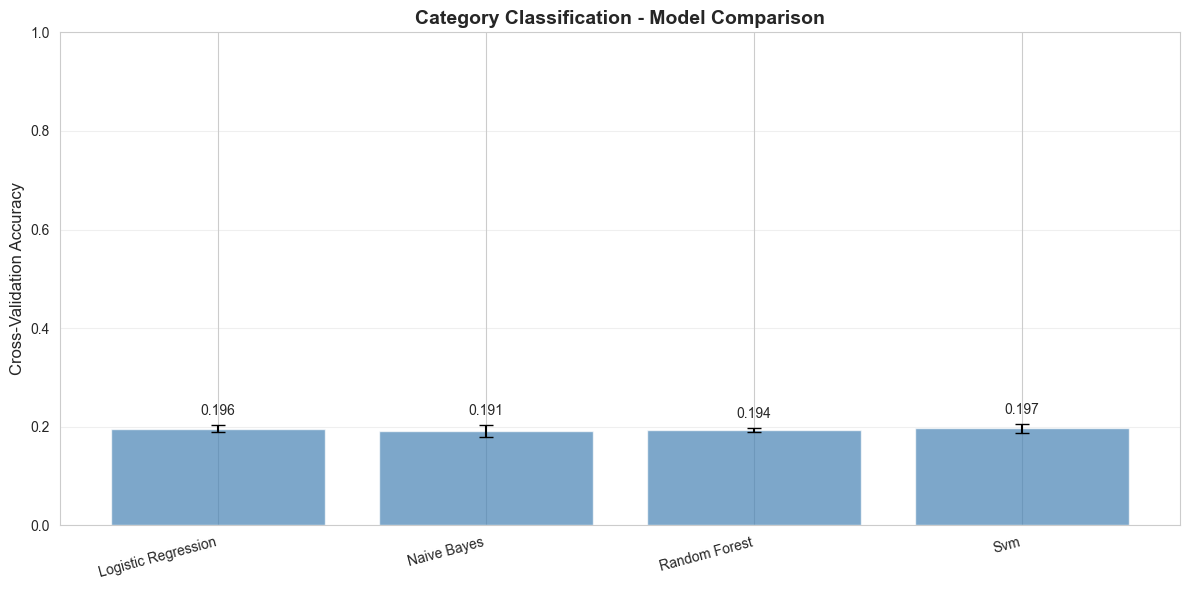

✓ Plot saved to: outputs/category_model_comparison.png


In [6]:
# Visualize category model comparison
plt.figure(figsize=(12, 6))

models = list(cat_results.keys())
cv_means = [cat_results[m]['cv_mean'] for m in models]
cv_stds = [cat_results[m]['cv_std'] for m in models]

x_pos = np.arange(len(models))
plt.bar(x_pos, cv_means, yerr=cv_stds, capsize=5, color='steelblue', alpha=0.7)
plt.xticks(x_pos, [m.replace('_', ' ').title() for m in models], rotation=15, ha='right')
plt.ylabel('Cross-Validation Accuracy', fontsize=12)
plt.title('Category Classification - Model Comparison', fontsize=14, fontweight='bold')
plt.ylim(0, 1.0)
plt.grid(axis='y', alpha=0.3)

# Add value labels
for i, (mean, std) in enumerate(zip(cv_means, cv_stds)):
    plt.text(i, mean + std + 0.02, f'{mean:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/category_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot saved to: outputs/category_model_comparison.png")

## 3. Train Priority Prediction Models

In [7]:
print("\n" + "="*80)
print("TRAINING PRIORITY PREDICTION MODELS")
print("="*80)

# Train all models
pri_models, pri_results, pri_comparison = train_all_models(
    X_train_pri, y_train_pri,
    model_types=['logistic_regression', 'naive_bayes', 'random_forest', 'svm']
)


TRAINING PRIORITY PREDICTION MODELS

Training logistic_regression...
✓ Cross-validation accuracy: 0.2459 (+/- 0.0101)
✓ Training accuracy: 0.5948

Training naive_bayes...
✓ Cross-validation accuracy: 0.2518 (+/- 0.0060)
✓ Training accuracy: 0.4987

Training random_forest...
✓ Cross-validation accuracy: 0.2438 (+/- 0.0062)
✓ Training accuracy: 0.9566

Training svm...
✓ Cross-validation accuracy: 0.2523 (+/- 0.0088)
✓ Training accuracy: 0.5358

MODEL COMPARISON
                    train_accuracy   cv_mean    cv_std
svm                       0.535793  0.252251  0.008787
naive_bayes               0.498745  0.251808  0.006039
logistic_regression       0.594834  0.245904  0.010069
random_forest             0.956605  0.243838  0.006185


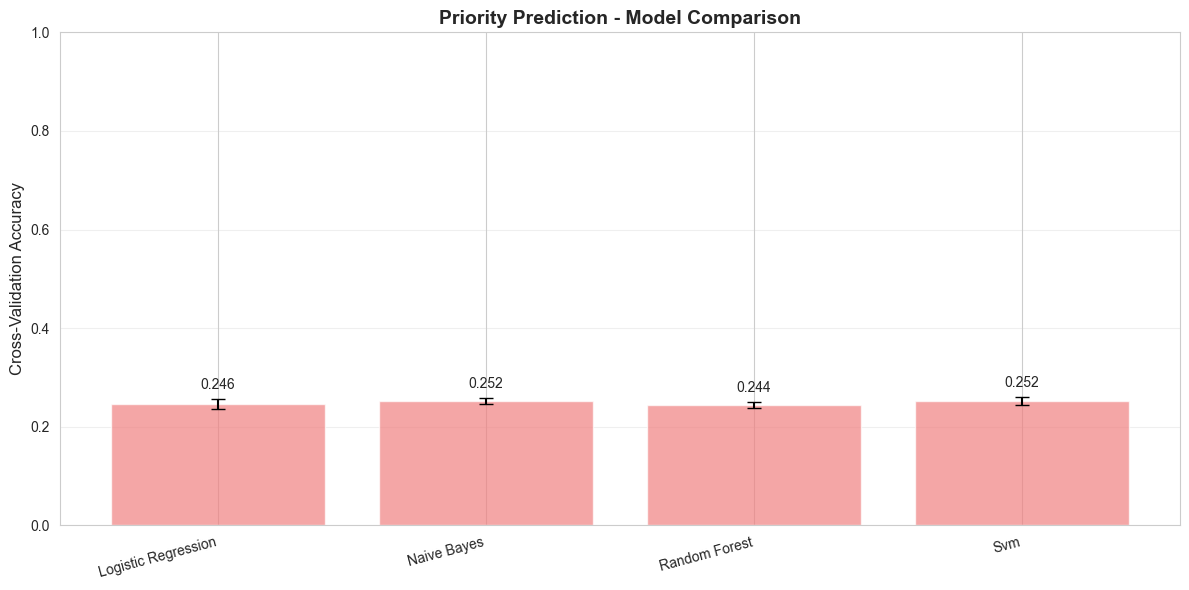

✓ Plot saved to: outputs/priority_model_comparison.png


In [8]:
# Visualize priority model comparison
plt.figure(figsize=(12, 6))

models = list(pri_results.keys())
cv_means = [pri_results[m]['cv_mean'] for m in models]
cv_stds = [pri_results[m]['cv_std'] for m in models]

x_pos = np.arange(len(models))
plt.bar(x_pos, cv_means, yerr=cv_stds, capsize=5, color='lightcoral', alpha=0.7)
plt.xticks(x_pos, [m.replace('_', ' ').title() for m in models], rotation=15, ha='right')
plt.ylabel('Cross-Validation Accuracy', fontsize=12)
plt.title('Priority Prediction - Model Comparison', fontsize=14, fontweight='bold')
plt.ylim(0, 1.0)
plt.grid(axis='y', alpha=0.3)

# Add value labels
for i, (mean, std) in enumerate(zip(cv_means, cv_stds)):
    plt.text(i, mean + std + 0.02, f'{mean:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/priority_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot saved to: outputs/priority_model_comparison.png")

## 4. Hyperparameter Tuning (Best Models)

In [9]:
# Get best model for category classification
best_cat_model_name = cat_comparison['cv_mean'].idxmax()
print(f"Best Category Classification Model: {best_cat_model_name}")
print(f"CV Accuracy: {cat_comparison.loc[best_cat_model_name, 'cv_mean']:.4f}")

# Tune hyperparameters
print("\nTuning hyperparameters...")
best_cat_classifier = cat_models[best_cat_model_name]
tuning_results_cat = best_cat_classifier.tune_hyperparameters(X_train_cat, y_train_cat)

Best Category Classification Model: svm
CV Accuracy: 0.1970

Tuning hyperparameters...

Tuning hyperparameters for svm...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
✓ Best parameters: {'C': 0.1, 'kernel': 'rbf'}
✓ Best CV score: 0.2075


In [10]:
# Get best model for priority prediction
best_pri_model_name = pri_comparison['cv_mean'].idxmax()
print(f"\nBest Priority Prediction Model: {best_pri_model_name}")
print(f"CV Accuracy: {pri_comparison.loc[best_pri_model_name, 'cv_mean']:.4f}")

# Tune hyperparameters
print("\nTuning hyperparameters...")
best_pri_classifier = pri_models[best_pri_model_name]
tuning_results_pri = best_pri_classifier.tune_hyperparameters(X_train_pri, y_train_pri)


Best Priority Prediction Model: svm
CV Accuracy: 0.2523

Tuning hyperparameters...

Tuning hyperparameters for svm...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
✓ Best parameters: {'C': 0.1, 'kernel': 'rbf'}
✓ Best CV score: 0.2587


## 5. Save Trained Models

In [11]:
# Save all category classification models
print("Saving category classification models...")
for model_name, classifier in cat_models.items():
    filepath = f'../models/category_{model_name}.pkl'
    classifier.save(filepath)

# Save all priority prediction models
print("\nSaving priority prediction models...")
for model_name, classifier in pri_models.items():
    filepath = f'../models/priority_{model_name}.pkl'
    classifier.save(filepath)

print("\n✓ All models saved successfully!")

Saving category classification models...
✓ Model saved to ../models/category_logistic_regression.pkl
✓ Model saved to ../models/category_naive_bayes.pkl
✓ Model saved to ../models/category_random_forest.pkl
✓ Model saved to ../models/category_svm.pkl

Saving priority prediction models...
✓ Model saved to ../models/priority_logistic_regression.pkl
✓ Model saved to ../models/priority_naive_bayes.pkl
✓ Model saved to ../models/priority_random_forest.pkl
✓ Model saved to ../models/priority_svm.pkl

✓ All models saved successfully!


In [12]:
# Save training results
cat_comparison.to_csv('../outputs/category_training_results.csv')
pri_comparison.to_csv('../outputs/priority_training_results.csv')

print("✓ Training results saved")

✓ Training results saved


## 6. Training Summary

In [13]:
print("\n" + "="*80)
print("MODEL TRAINING COMPLETE!")
print("="*80)

print("\nCategory Classification Results:")
print("-"*80)
print(cat_comparison[['train_accuracy', 'cv_mean', 'cv_std']].to_string())
print(f"\nBest Model: {best_cat_model_name}")
print(f"Best CV Accuracy: {cat_comparison.loc[best_cat_model_name, 'cv_mean']:.4f}")

print("\n\nPriority Prediction Results:")
print("-"*80)
print(pri_comparison[['train_accuracy', 'cv_mean', 'cv_std']].to_string())
print(f"\nBest Model: {best_pri_model_name}")
print(f"Best CV Accuracy: {pri_comparison.loc[best_pri_model_name, 'cv_mean']:.4f}")

print("\n\nNext Steps:")
print("1. Evaluate models on test set → 05_evaluation.ipynb")
print("2. Analyze confusion matrices")
print("3. Perform error analysis")
print("4. Generate final report")


MODEL TRAINING COMPLETE!

Category Classification Results:
--------------------------------------------------------------------------------
                    train_accuracy   cv_mean    cv_std
svm                       0.498007  0.197048  0.008917
logistic_regression       0.567528  0.196458  0.008076
random_forest             0.954982  0.193948  0.003746
naive_bayes               0.457417  0.191292  0.012888

Best Model: svm
Best CV Accuracy: 0.1970


Priority Prediction Results:
--------------------------------------------------------------------------------
                    train_accuracy   cv_mean    cv_std
svm                       0.535793  0.252251  0.008787
naive_bayes               0.498745  0.251808  0.006039
logistic_regression       0.594834  0.245904  0.010069
random_forest             0.956605  0.243838  0.006185

Best Model: svm
Best CV Accuracy: 0.2523


Next Steps:
1. Evaluate models on test set → 05_evaluation.ipynb
2. Analyze confusion matrices
3. Perform error